In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("stock_shiller-pe.xlsx")
df.head()

,Date,Value
0,2026-04-23 00:00:00,40.34
1,2026-04-01 00:00:00,38.34
2,2026-03-01 00:00:00,37.66
3,2026-02-01 00:00:00,39.53
4,2026-01-01 00:00:00,40.03


In [3]:
df.head()

,Date,Value
0,2026-04-23 00:00:00,40.34
1,2026-04-01 00:00:00,38.34
2,2026-03-01 00:00:00,37.66
3,2026-02-01 00:00:00,39.53
4,2026-01-01 00:00:00,40.03


In [4]:
df.dtypes

Date     object
Value       str
dtype: object

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df['Value'] = pd.to_numeric(df['Value'].str.strip())

df = df.sort_values(by='Date', ascending=True)
df.reset_index(drop=True, inplace=True)

<Axes: >

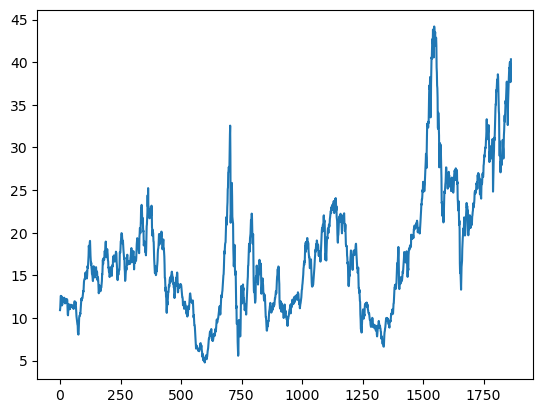

In [49]:
df['Value'].plot()

In [50]:
stand_dev_1 = df['Value'].mean() + df['Value'].std()
stand_dev_2 = df['Value'].mean() - df['Value'].std()

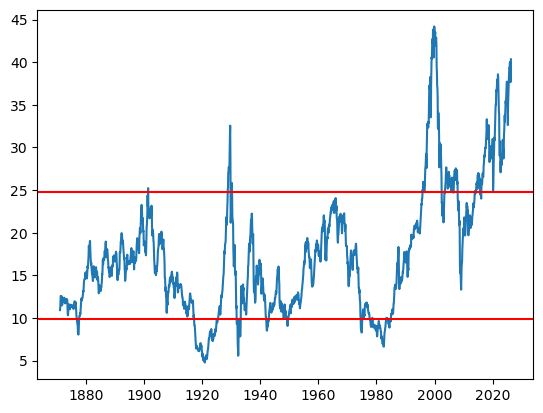

In [51]:
fig, ax = plt.subplots()
ax.plot(df['Date'], df['Value'])
ax.axhline(y=stand_dev_1, color='red')
ax.axhline(y=stand_dev_2, color='red')

<Axes: >

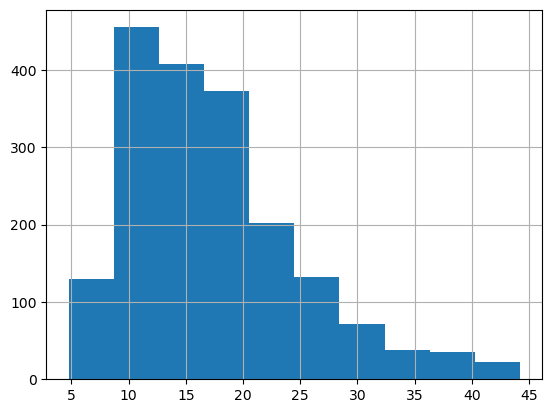

In [52]:
df['Value'].hist()

<Axes: >

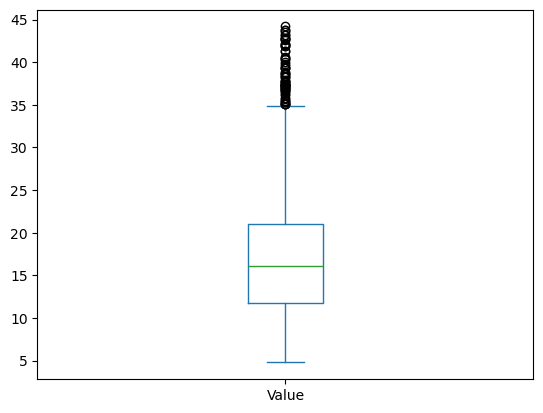

In [53]:
df['Value'].plot(kind='box')

In [54]:
df['Value'].mean(), df['Value'].std()

(np.float64(17.37628755364807), np.float64(7.457570348791707))

In [55]:
# Calculate Velocity
df['roc_12m'] = df['Value'].pct_change(periods=12)
# Normalize
df['roc_zscore'] = (df['roc_12m'] - df['roc_12m'].mean()) / df['roc_12m'].std()
df

,Date,Value,roc_12m,roc_zscore
0,1871-02-01,10.92,NaN,NaN
1,1871-03-01,11.19,NaN,NaN
2,1871-04-01,12.05,NaN,NaN
3,1871-05-01,12.59,NaN,NaN
4,1871-06-01,12.59,NaN,NaN
...,...,...,...,...
1859,2026-01-01,40.03,0.077814,0.280665
1860,2026-02-01,39.53,0.062920,0.201327
1861,2026-03-01,37.66,0.082495,0.305602
1862,2026-04-01,38.34,0.174992,0.798336


<Axes: >

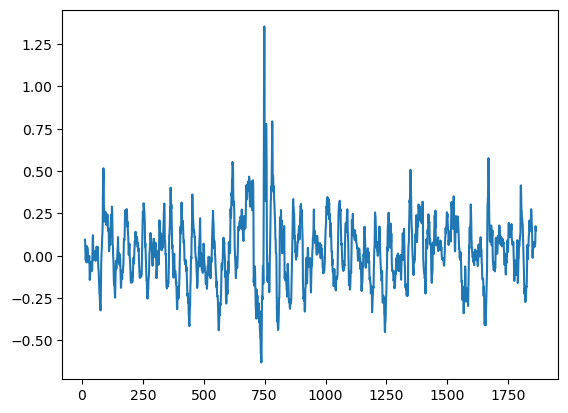

In [56]:
df['roc_12m'].plot()

<Axes: >

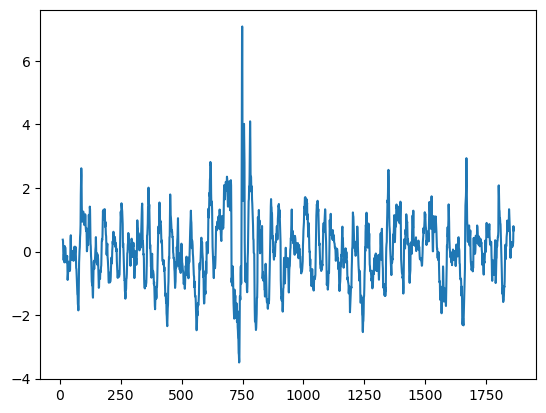

In [57]:
df['roc_zscore'].plot()

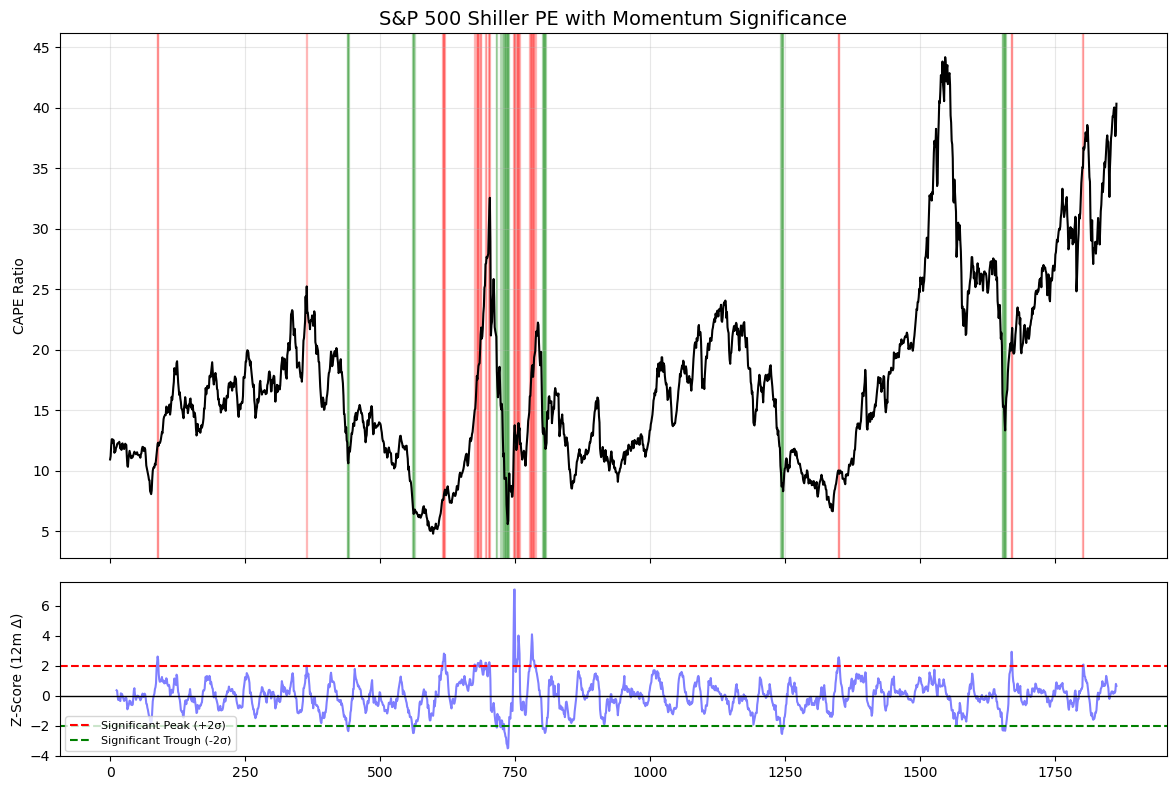

In [58]:
# 4. VISUALIZE: Create the Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})

# Top Plot: Shiller PE Ratio
ax1.plot(df.index, df['Value'], color='black', lw=1.5, label='Shiller PE')
ax1.set_title('S&P 500 Shiller PE with Momentum Significance', fontsize=14)
ax1.set_ylabel('CAPE Ratio')
ax1.grid(alpha=0.3)

# Bottom Plot: The Z-Score (The Signal)
ax2.plot(df.index, df['roc_zscore'], color='blue', alpha=0.5)
ax2.axhline(0, color='black', lw=1)
ax2.axhline(2, color='red', linestyle='--', label='Significant Peak (+2σ)')
ax2.axhline(-2, color='green', linestyle='--', label='Significant Trough (-2σ)')
ax2.set_ylabel('Z-Score (12m Δ)')
ax2.legend(loc='lower left', fontsize=8)

# 5. HIGHLIGHT SIGNIFICANCE: Shade the background where Z > 2 or Z < -2
# This identifies the "peaks and troughs" you were looking for.
for i in range(1, len(df)):
    z = df['roc_zscore'].iloc[i]
    if z > 2:
        ax1.axvspan(df.index[i-1], df.index[i], color='red', alpha=0.2)
    elif z < -2:
        ax1.axvspan(df.index[i-1], df.index[i], color='green', alpha=0.2)

plt.tight_layout()
plt.show()

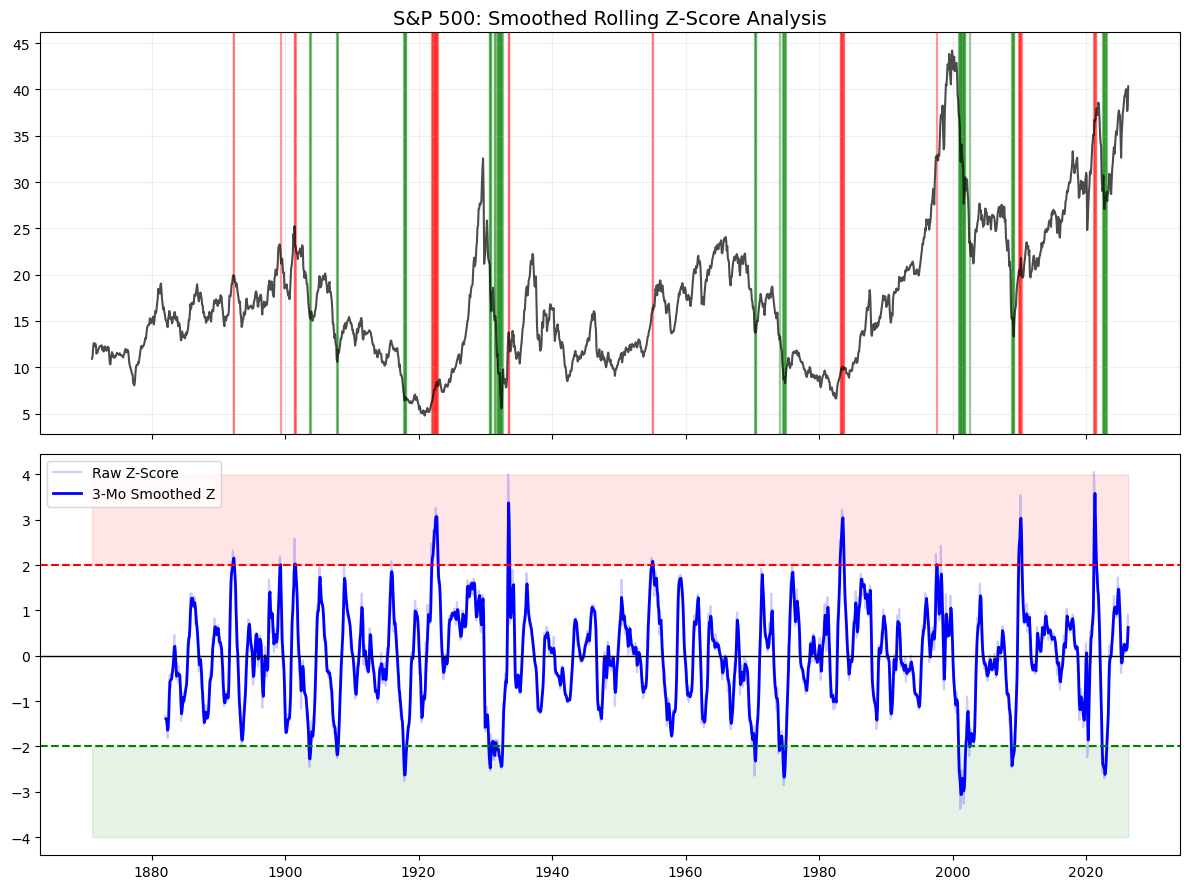

In [59]:
# 2. PARAMETERS
WINDOW_SIZE = 120  # 10-year rolling window (120 months)
SMOOTHING_PERIOD = 3 # 3-month window to smooth the Z-score signal
df = df.set_index('Date')

# Calculate rolling mean and std of the RoC
df['rolling_mu'] = df['roc_12m'].rolling(window=WINDOW_SIZE).mean()
df['rolling_sigma'] = df['roc_12m'].rolling(window=WINDOW_SIZE).std()

# Calculate the Rolling Z-Score
df['rolling_zscore'] = (df['roc_12m'] - df['rolling_mu']) / df['rolling_sigma']

# 4. SMOOTH THE SIGNAL
# This reduces "false positive" spikes
df['smoothed_z'] = df['rolling_zscore'].rolling(window=SMOOTHING_PERIOD).mean()

# 5. VISUALIZE
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# Top Plot: CAPE Ratio
ax1.plot(df.index, df['Value'], color='black', label='Shiller PE', alpha=0.7)
ax1.set_title('S&P 500: Smoothed Rolling Z-Score Analysis', fontsize=14)
ax1.grid(alpha=0.2)

# Bottom Plot: Smoothed Z-Score
ax2.plot(df.index, df['rolling_zscore'], color='blue', alpha=0.2, label='Raw Z-Score')
ax2.plot(df.index, df['smoothed_z'], color='blue', lw=2, label=f'{SMOOTHING_PERIOD}-Mo Smoothed Z')
ax2.axhline(0, color='black', lw=1)
ax2.axhline(2, color='red', linestyle='--')
ax2.axhline(-2, color='green', linestyle='--')
ax2.fill_between(df.index, 2, 4, color='red', alpha=0.1) # Overheated Zone
ax2.fill_between(df.index, -2, -4, color='green', alpha=0.1) # Value Zone
ax2.legend(loc='upper left')

# Highlight sustained significant periods
# We use the 'smoothed_z' to decide when to shade the background
for i in range(1, len(df)):
    z = df['smoothed_z'].iloc[i]
    if z > 2:
        ax1.axvspan(df.index[i-1], df.index[i], color='red', alpha=0.3)
    elif z < -2:
        ax1.axvspan(df.index[i-1], df.index[i], color='green', alpha=0.3)

plt.tight_layout()
plt.show()

In [60]:
yield_df = pd.read_csv("GS10.csv")
yield_df['Date'] = pd.to_datetime(yield_df['observation_date'])
yield_df['Yield'] = pd.to_numeric(yield_df['GS10'])
yield_df.head()

,observation_date,GS10,Date,Yield
0,1953-04-01,2.83,1953-04-01,2.83
1,1953-05-01,3.05,1953-05-01,3.05
2,1953-06-01,3.11,1953-06-01,3.11
3,1953-07-01,2.93,1953-07-01,2.93
4,1953-08-01,2.95,1953-08-01,2.95


In [61]:
df

,Value,roc_12m,roc_zscore,rolling_mu,rolling_sigma,rolling_zscore,smoothed_z
Date,,,,,,,
1871-02-01,10.92,NaN,NaN,NaN,NaN,NaN,NaN
1871-03-01,11.19,NaN,NaN,NaN,NaN,NaN,NaN
1871-04-01,12.05,NaN,NaN,NaN,NaN,NaN,NaN
1871-05-01,12.59,NaN,NaN,NaN,NaN,NaN,NaN
1871-06-01,12.59,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2026-01-01,40.03,0.077814,0.280665,0.046063,0.138052,0.229991,0.122174
2026-02-01,39.53,0.062920,0.201327,0.047513,0.137300,0.112215,0.141753
2026-03-01,37.66,0.082495,0.305602,0.048625,0.137036,0.247165,0.196457


In [62]:
df = df.merge(yield_df, on='Date', how='left')
df

,Date,Value,roc_12m,roc_zscore,rolling_mu,rolling_sigma,rolling_zscore,smoothed_z,observation_date,GS10,Yield
0,1871-02-01,10.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1871-03-01,11.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1871-04-01,12.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1871-05-01,12.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1871-06-01,12.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1859,2026-01-01,40.03,0.077814,0.280665,0.046063,0.138052,0.229991,0.122174,2026-01-01,4.21,4.21
1860,2026-02-01,39.53,0.062920,0.201327,0.047513,0.137300,0.112215,0.141753,2026-02-01,4.13,4.13
1861,2026-03-01,37.66,0.082495,0.305602,0.048625,0.137036,0.247165,0.196457,2026-03-01,4.25,4.25
1862,2026-04-01,38.34,0.174992,0.798336,0.050353,0.137313,0.907702,0.422360,NaN,NaN,NaN


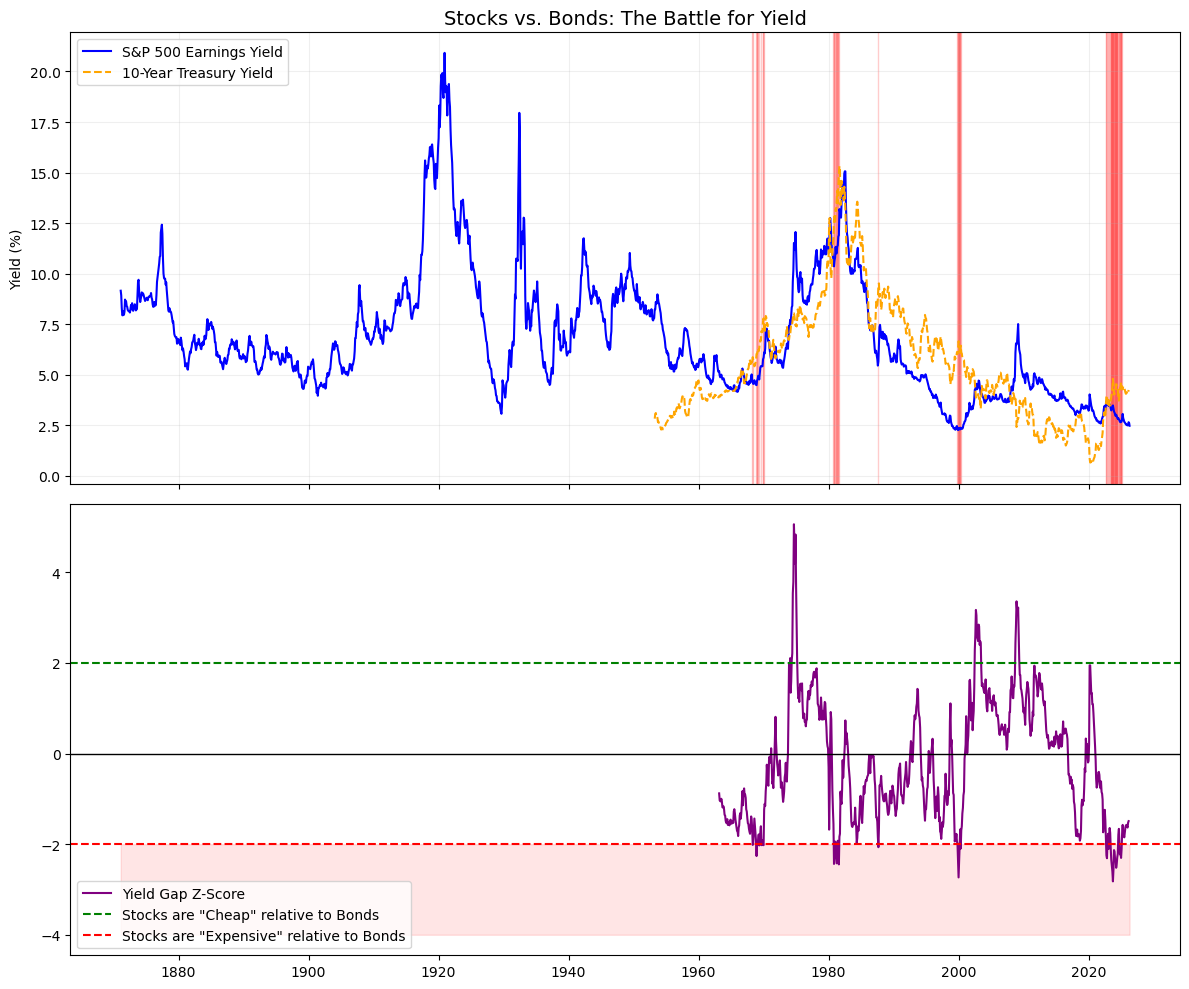

In [68]:
df.set_index('Date', inplace=True)
# 2. CALCULATE YIELDS
# Convert PE to a percentage yield (e.g., 20 PE -> 5.0%)
df['earnings_yield'] = (1 / df['Value']) * 100

# Calculate the Yield Gap (Stocks minus Bonds)
# A positive gap means stocks pay more than bonds; negative means bonds pay more.
df['yield_gap'] = df['earnings_yield'] - df['Yield']

# 3. CALCULATE THE ROLLING Z-SCORE OF THE GAP
WINDOW = 120 # 10-year rolling window
df['gap_mu'] = df['yield_gap'].rolling(window=WINDOW).mean()
df['gap_sigma'] = df['yield_gap'].rolling(window=WINDOW).std()
df['gap_zscore'] = (df['yield_gap'] - df['gap_mu']) / df['gap_sigma']

# 4. VISUALIZATION
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Top Plot: The Two Yields
ax1.plot(df.index, df['earnings_yield'], label='S&P 500 Earnings Yield', color='blue', lw=1.5)
ax1.plot(df.index, df['Yield'], label='10-Year Treasury Yield', color='orange', lw=1.5, linestyle='--')
ax1.set_title('Stocks vs. Bonds: The Battle for Yield', fontsize=14)
ax1.set_ylabel('Yield (%)')
ax1.legend()
ax1.grid(alpha=0.2)

# Bottom Plot: The Yield Gap Z-Score
ax2.plot(df.index, df['gap_zscore'], color='purple', label='Yield Gap Z-Score')
ax2.axhline(0, color='black', lw=1)
ax2.axhline(2, color='green', linestyle='--', label='Stocks are "Cheap" relative to Bonds')
ax2.axhline(-2, color='red', linestyle='--', label='Stocks are "Expensive" relative to Bonds')
ax2.fill_between(df.index, -2, -4, color='red', alpha=0.1) # Danger Zone
ax2.legend(loc='lower left')

# Highlight Regimes
for i in range(1, len(df)):
    if df['gap_zscore'].iloc[i] < -2:
        ax1.axvspan(df.index[i-1], df.index[i], color='red', alpha=0.2)

plt.tight_layout()
plt.show()

In [69]:
df.tail()

,Value,roc_12m,roc_zscore,rolling_mu,rolling_sigma,rolling_zscore,smoothed_z,observation_date,GS10,Yield,earnings_yield,yield_gap,gap_mu,gap_sigma,gap_zscore
Date,,,,,,,,,,,,,,,
2026-01-01,40.03,0.077814,0.280665,0.046063,0.138052,0.229991,0.122174,2026-01-01,4.21,4.21,2.498126,-1.711874,0.483531,1.343834,-1.633688
2026-02-01,39.53,0.062920,0.201327,0.047513,0.137300,0.112215,0.141753,2026-02-01,4.13,4.13,2.529724,-1.600276,0.450307,1.345671,-1.523837
2026-03-01,37.66,0.082495,0.305602,0.048625,0.137036,0.247165,0.196457,2026-03-01,4.25,4.25,2.655337,-1.594663,0.419921,1.350367,-1.491878
2026-04-01,38.34,0.174992,0.798336,0.050353,0.137313,0.907702,0.422360,NaN,NaN,NaN,2.608242,NaN,NaN,NaN,NaN
2026-04-23,40.34,0.149943,0.664898,0.051951,0.137347,0.713462,0.622776,NaN,NaN,NaN,2.478929,NaN,NaN,NaN,NaN
